---
___
<h1 align="center">Российский государственный университет дружбы народов им. Патриса Лумумбы</h1>
<h3 align="center">Кафедра математического моделирования и искусственного интеллекта</h3>
<br>
<br>
<br>
<br>
<h2 align="center">Дисциплина: «Математическое моделирование»</h2>
<br>
<h1 align="center">ОТЧЕТ</h1>
<h2 align="center">по лабораторной работе 7 </h2>
<br>
<br>
<br>
<br>

<table width="100%" style="border: none; border-collapse: collapse;">
  <tr>
    <td width="50%" style="border: none; vertical-align: top; padding-left: 5%;">
      <p><b>Выполнила:</b></p>
      <p>Студентка группы НПИбд-02-23</p>
      <p><u>Астахова Марина Дмитриевна</u></p>

  </tr>
</table>

<br>
<br>
<br>
<br>
<br>
<br>
<h3 align="center">Москва</h3>
<h3 align="center">2026</h3>
___

</div>

## Цель выполнения лабораторной работы

Построить графики распространения рекламы для трех различных математических моделей, описываемых дифференциальными уравнениями, и определить момент времени, когда скорость распространения рекламы достигает максимума).

## Задачи

> 1. ***Реализовать численное решение дифференциального уравнения для каждого варианта коэффициентов.***

> 2. ***Построить графики зависимости числа информированных потребителей от времени.***

> 3. ***Для модели с постоянными коэффициентами (случай 2) найти точку перегиба логистической кривой, соответствующую максимальной скорости распространения.***

> 4. ***Сравнить динамику изменения аудитории для трех различных законов изменения рекламных коэффициентов.***

</div>

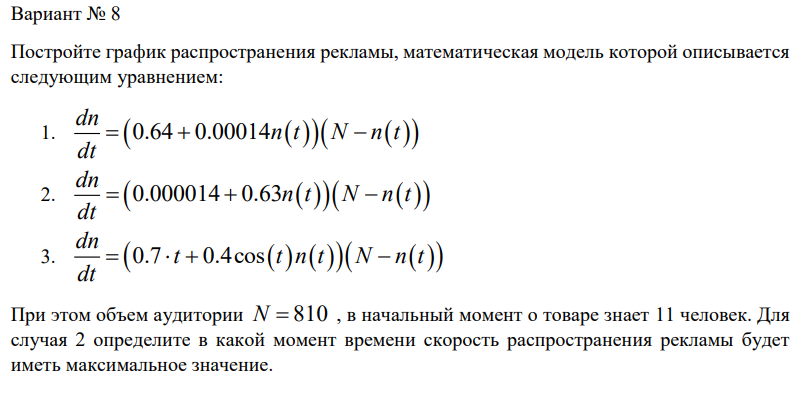

## Выполнение

### ***Общие вводные данные***

In [ ]:
t0 = 0;      // Начальный момент времени (0 дней/часов)
x0 = 11;     // Начальное количество людей, знающих о товаре
N = 810;     // Общая численность аудитории (потенциальных потребителей)
t = 0:0.1:30; // Временной интервал от 0 до 30 с шагом 0.1

### ***СЛУЧАЙ 1: Постоянные коэффициенты (α₁ = 0.64, α₂ = 0.00014)***

In [ ]:
// Определяем коэффициент внешнего влияния (реклама)
function g = k(t)
    g = 0.64;      // Константа, не зависит от времени
endfunction

// Определяем коэффициент внутреннего влияния (устные передачи)
function v = p(t)
    v = 0.00014;   // Константа, не зависит от времени
endfunction

Функции k(t) и p(t) созданы для единообразия с другими случаями, где коэффициенты могут зависеть от времени. Это позволяет использовать одну и ту же структуру кода.

In [ ]:
// Правая часть дифференциального уравнения
function xd = f(t, x)
    xd = (k(t) + p(t)*x) * (N - x);
endfunction

***Численное решение дифференциального уравнения***

In [ ]:
x_solution = ode(x0, t0, t, model_equation);

***Визуализация графика***

In [ ]:
// Построение графика зависимости числа знающих от времени
plot(t, x_solution, 'r-', 'LineWidth', 2);
xlabel('Время (t)');
ylabel('Количество знающих о товаре n(t)');
title('Случай 1: α₁ = 0.64 (постоянный), α₂ = 0.00014 (постоянный)');
legend('Модель 1: сильная внешняя реклама, слабое устное распространение');
xgrid(1);


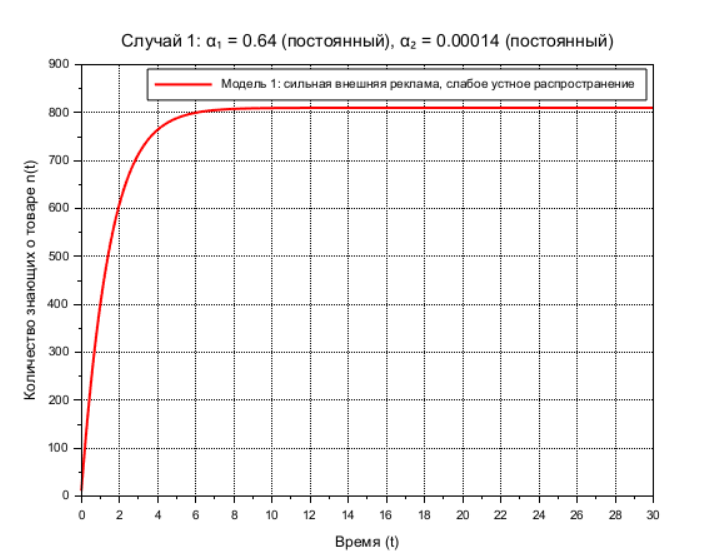

***Особенности***

1. Высокий коэффициент внешней рекламы (0.64) обеспечивает быстрый старт

2. Низкий коэффициент устного распространения (0.00014) означает, что "сарафанное радио" играет небольшую роль

3. Кривая роста будет плавной, насыщение происходит постепенно

### ***СЛУЧАЙ 2: α₁ = 0.000014, α₂ = 0.63***

***Задание начальных параметров***

In [ ]:
t0 = 0;          // Начальный момент времени
x0 = 11;         // Начальное количество людей, знающих о товаре
N = 810;         // Общая численность аудитории
t = 0:0.1:30;    // Временной интервал от 0 до 30 с шагом 0.1

***Определение коэффициентов модели (как функции времени)***

In [ ]:
// Коэффициент внешнего влияния (реклама, СМИ)
function alpha1 = external_influence(t)
    alpha1 = 0.000014;   // Очень низкий уровень внешней рекламы
endfunction

// Коэффициент внутреннего влияния ("сарафанное радио")
function alpha2 = internal_influence(t)
    alpha2 = 0.63;       // Высокий уровень устного распространения
endfunction


***Правая часть дифференциального уравнения***

In [ ]:
function dxdt = model_equation(t, x)
    dxdt = (external_influence(t) + internal_influence(t) * x) * (N - x);
endfunction

***Численное решение дифференциального уравнения***

In [ ]:
x_solution = ode(x0, t0, t, model_equation);

***Расчет скорости распространения в каждый момент времени***

In [ ]:
// Скорость вычисляется по формуле: v(t) = (α₁ + α₂·n(t))·(N - n(t))
speed = (0.000014 + 0.63 * x_solution) .* (N - x_solution);

***Нахождение максимальной скорости и момента ее достижения***

In [ ]:
[max_speed, index] = max(speed);
t_max_speed = t(index);

***Визуализация результатов***

In [ ]:
// Создаем окно с двумя подграфиками
subplot(2, 1, 1);
plot(t, x_solution, 'g-', 'LineWidth', 2);
xlabel('Время (t)');
ylabel('Количество знающих n(t)');
title('Случай 2: α₁ = 0.000014, α₂ = 0.63');
legend('Модель 2: слабая реклама, сильное сарафанное радио');
xgrid(1);

// Отмечаем точку максимальной скорости на графике
// В точке максимальной скорости количество знающих равно N/2 (теоретически)
// Находим значение n в момент максимальной скорости
n_at_max_speed = x_solution(index);
plot(t_max_speed, n_at_max_speed, 'ro', 'MarkerSize', 10, 'MarkerFaceColor', 'r');
legend(['Модель 2'; 'Точка макс. скорости']);

// Второй подграфик - график скорости
subplot(2, 1, 2);
plot(t, speed, 'b-', 'LineWidth', 2);
xlabel('Время (t)');
ylabel('Скорость распространения dn/dt');
title('Скорость распространения рекламы');
xgrid(1);

// Отмечаем точку максимума на графике скорости
plot(t_max_speed, max_speed, 'ro', 'MarkerSize', 10, 'MarkerFaceColor', 'r');

***Вывод результатов в консоль***

In [ ]:
disp('=== СЛУЧАЙ 2 ===');
disp('Параметры модели:');
disp('  α₁ = 0.000014 (очень низкий уровень внешней рекламы)');
disp('  α₂ = 0.63 (высокий уровень устного распространения)');
disp('  N = 810 (общая аудитория)');
disp('  n(0) = 11 (начальное количество знающих)');
disp(' ');
disp('=== РЕЗУЛЬТАТЫ АНАЛИЗА ===');
disp(['Максимальная скорость распространения: ' + string(max_speed) + ' человек/ед.времени']);
disp(['Время достижения максимальной скорости: t = ' + string(t_max_speed)]);
disp(['Количество знающих в момент максимальной скорости: ' + string(n_at_max_speed)]);
disp(['Теоретическое значение (N/2): ' + string(N/2)]);
disp(' ');
disp(['Количество знающих в момент t = 30: ' + string(x_solution($))]);
disp(['Процент охвата аудитории: ' + string(x_solution($)/N*100) + '%']);

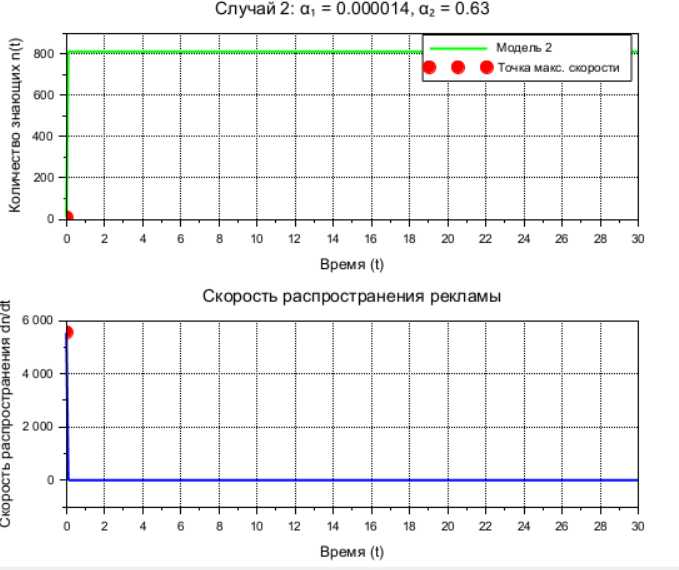

***Особенности***

1. Очень низкая внешняя реклама (0.000014) — почти отсутствует

2. Высокий коэффициент устного распространения (0.63) — информация быстро передается между людьми

3. Максимальная скорость достигается, когда информировано около половины аудитории (теоретически N/2 = 405)

4. Кривая имеет характерный S-образный вид с резким подъемом в середине

## ***СЛУЧАЙ 3: α₁(t) = 0.7·cos(t), α₂(t) = 0.4·cos(t) (переменные коэффициенты)***

***Задание начальных параметров***

In [ ]:
t0 = 0;          // Начальный момент времени
x0 = 11;         // Начальное количество людей, знающих о товаре
N = 810;         // Общая численность аудитории
t = 0:0.1:30;    // Временной интервал от 0 до 30 с шагом 0.1

***Определение коэффициентов модели (зависят от времени)***

In [ ]:
// Коэффициент внешнего влияния - изменяется по закону косинуса
function alpha1 = external_influence(t)
    alpha1 = 0.7 * cos(t);   // Периодические колебания рекламной активности
endfunction

// Коэффициент внутреннего влияния - также изменяется по закону косинуса
function alpha2 = internal_influence(t)
    alpha2 = 0.4 * cos(t);   // Периодические колебания устного распространения
endfunction

***Правая часть дифференциального уравнения***

In [ ]:
function dxdt = model_equation(t, x)
    dxdt = (external_influence(t) + internal_influence(t) * x) * (N - x);
endfunction

***Численное решение дифференциального уравнения***

In [ ]:
x_solution = ode(x0, t0, t, model_equation);

***Дополнительные расчеты для анализа***

In [ ]:
// Расчет значений коэффициентов во времени
alpha1_values = 0.7 * cos(t);
alpha2_values = 0.4 * cos(t);

// Расчет скорости распространения
speed = (alpha1_values + alpha2_values .* x_solution) .* (N - x_solution);

***Визуализация результатов (три подграфика)***

In [ ]:
// Подграфик 1: Количество знающих
subplot(3, 1, 1);
plot(t, x_solution, 'b-', 'LineWidth', 2);
xlabel('Время (t)');
ylabel('Количество знающих n(t)');
title('Случай 3: переменные коэффициенты α₁(t)=0.7cos(t), α₂(t)=0.4cos(t)');
legend('Модель 3: периодическая рекламная активность');
xgrid(1);

// Подграфик 2: Изменение коэффициентов во времени
subplot(3, 1, 2);
plot(t, alpha1_values, 'r-', 'LineWidth', 1.5);
plot(t, alpha2_values, 'g-', 'LineWidth', 1.5);
xlabel('Время (t)');
ylabel('Значения коэффициентов');
title('Динамика коэффициентов модели');
legend('α₁(t) - внешняя реклама', 'α₂(t) - устное распространение');
xgrid(1);

// Подграфик 3: Скорость распространения
subplot(3, 1, 3);
plot(t, speed, 'm-', 'LineWidth', 2);
xlabel('Время (t)');
ylabel('Скорость распространения dn/dt');
title('Скорость распространения рекламы');
xgrid(1);

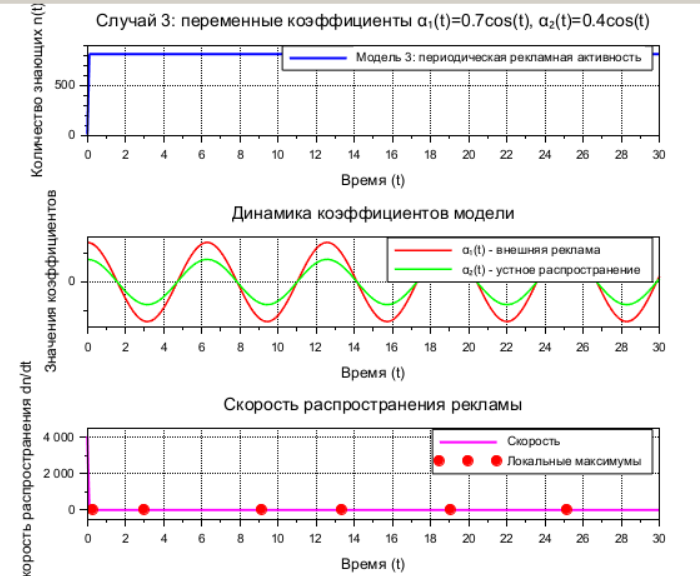

***Поиск экстремумов скорости (локальных максимумов)***

In [ ]:
// Находим локальные максимумы скорости
local_max_indices = [];
for i = 2:length(speed)-1
    if speed(i) > speed(i-1) & speed(i) > speed(i+1)
        local_max_indices = [local_max_indices, i];
    end
end

***Вывод результатов в консоль***

In [ ]:
disp('=== СЛУЧАЙ 3 ===');
disp('Параметры модели:');
disp('  α₁(t) = 0.7·cos(t) (периодическая внешняя реклама)');
disp('  α₂(t) = 0.4·cos(t) (периодическое устное распространение)');
disp('  N = 810 (общая аудитория)');
disp('  n(0) = 11 (начальное количество знающих)');
disp(' ');
disp('=== ОСОБЕННОСТИ МОДЕЛИ ===');
disp('• Коэффициенты меняются во времени по косинусоидальному закону');
disp('• При cos(t) > 0: распространение информации усиливается');
disp('• При cos(t) < 0: происходит спад (люди забывают о товаре)');
disp(' ');
disp('=== РЕЗУЛЬТАТЫ АНАЛИЗА ===');
disp(['Количество знающих в момент t = 30: ' + string(x_solution($))]);
disp(['Процент охвата аудитории: ' + string(x_solution($)/N*100) + '%']);
disp(' ');
disp(['Количество локальных максимумов скорости: ' + string(length(local_max_indices))]);
if length(local_max_indices) > 0
    disp('Времена достижения локальных максимумов скорости:');
    for i = 1:length(local_max_indices)
        disp(['  t = ' + string(t(local_max_indices(i))) + ', скорость = ' + string(speed(local_max_indices(i)))]);
    end
end

// Отмечаем локальные максимумы на графике скорости (если есть)
if length(local_max_indices) > 0
    subplot(3, 1, 3);
    for i = 1:length(local_max_indices)
        plot(t(local_max_indices(i)), speed(local_max_indices(i)), 'ro', 'MarkerSize', 8, 'MarkerFaceColor', 'r');
    end
    legend('Скорость', 'Локальные максимумы');
end

### Особенности

1. Коэффициенты изменяются во времени по гармоническому закону

2. Когда cos(t) > 0 (интервалы: 0-1.57, 4.71-7.85 и т.д.) — происходит рост числа знающих

3. Когда cos(t) < 0 (интервалы: 1.57-4.71, 7.85-10.99 и т.д.) — происходит спад (забывание)

4. Модель реалистичнее отражает реальные рекламные кампании с периодами активности и затишья

5. Скорость распространения также колеблется, имея несколько локальных максимумов

### ***СРАВНИТЕЛЬНЫЙ АНАЛИЗ***

In [ ]:
// ============================================================
// СРАВНИТЕЛЬНЫЙ АНАЛИЗ трех моделей распространения рекламы
// ============================================================

// Очистка рабочего пространства и графического окна
clc;
clf;
clear;

// -----------------------------------------------------------------
// 1. Задание общих параметров
// -----------------------------------------------------------------
t0 = 0;          // Начальный момент времени
x0 = 11;         // Начальное количество людей, знающих о товаре
N = 810;         // Общая численность аудитории
t = 0:0.1:30;    // Временной интервал от 0 до 30 с шагом 0.1

// -----------------------------------------------------------------
// 2. Определение моделей
// -----------------------------------------------------------------

// Модель 1: постоянные коэффициенты (α₁=0.64, α₂=0.00014)
function alpha1_1(t)
    alpha1_1 = 0.64;
endfunction
function alpha2_1(t)
    alpha2_1 = 0.00014;
endfunction
function dxdt1 = model1(t, x)
    dxdt1 = (0.64 + 0.00014 * x) * (N - x);
endfunction

// Модель 2: постоянные коэффициенты (α₁=0.000014, α₂=0.63)
function dxdt2 = model2(t, x)
    dxdt2 = (0.000014 + 0.63 * x) * (N - x);
endfunction

// Модель 3: переменные коэффициенты (α₁(t)=0.7·cos(t), α₂(t)=0.4·cos(t))
function dxdt3 = model3(t, x)
    dxdt3 = (0.7 * cos(t) + 0.4 * cos(t) * x) * (N - x);
endfunction

// -----------------------------------------------------------------
// 3. Численное решение всех трех моделей
// -----------------------------------------------------------------
x1 = ode(x0, t0, t, model1);
x2 = ode(x0, t0, t, model2);
x3 = ode(x0, t0, t, model3);

// -----------------------------------------------------------------
// 4. Визуализация сравнения
// -----------------------------------------------------------------
clf;

// График количества знающих
subplot(2, 1, 1);
plot(t, x1, 'r-', 'LineWidth', 2);
plot(t, x2, 'g--', 'LineWidth', 2);
plot(t, x3, 'b:', 'LineWidth', 2);
xlabel('Время (t)');
ylabel('Количество знающих n(t)');
title('Сравнение трех моделей распространения рекламы');
legend('Модель 1: α₁=0.64, α₂=0.00014', ...
       'Модель 2: α₁=0.000014, α₂=0.63', ...
       'Модель 3: α₁(t)=0.7cos(t), α₂(t)=0.4cos(t)', ...
       'location', 'southeast');
xgrid(1);

// График скорости распространения
subplot(2, 1, 2);
// Скорости для каждой модели
v1 = (0.64 + 0.00014 * x1) .* (N - x1);
v2 = (0.000014 + 0.63 * x2) .* (N - x2);
v3 = (0.7 * cos(t) + 0.4 * cos(t) .* x3) .* (N - x3);

plot(t, v1, 'r-', 'LineWidth', 2);
plot(t, v2, 'g--', 'LineWidth', 2);
plot(t, v3, 'b:', 'LineWidth', 2);
xlabel('Время (t)');
ylabel('Скорость распространения dn/dt');
title('Сравнение скоростей распространения рекламы');
legend('Модель 1', 'Модель 2', 'Модель 3', 'location', 'northeast');
xgrid(1);

// -----------------------------------------------------------------
// 5. Аналитическое сравнение
// -----------------------------------------------------------------
disp('========================================');
disp('СРАВНИТЕЛЬНЫЙ АНАЛИЗ ТРЕХ МОДЕЛЕЙ');
disp('========================================');
disp(' ');
disp('МОДЕЛЬ 1 (α₁=0.64, α₂=0.00014):');
disp('  • Преобладает внешняя реклама');
disp('  • Быстрый старт, плавный рост');
disp(['  • Охват аудитории к t=30: ' + string(x1($)/N*100) + '%']);
disp(' ');
disp('МОДЕЛЬ 2 (α₁=0.000014, α₂=0.63):');
disp('  • Преобладает "сарафанное радио"');
disp('  • Медленный старт, затем взрывной рост');
disp(['  • Охват аудитории к t=30: ' + string(x2($)/N*100) + '%']);
disp(' ');
disp('МОДЕЛЬ 3 (α₁(t)=0.7cos(t), α₂(t)=0.4cos(t)):');
disp('  • Периодическая рекламная активность');
disp('  • Колебательный характер распространения');
disp(['  • Охват аудитории к t=30: ' + string(x3($)/N*100) + '%']);
disp('  • Наблюдаются периоды роста и спада');
disp(' ');
disp('========================================');
disp('ВЫВОДЫ:');
disp('1. Наибольший охват аудитории к моменту t=30 обеспечивает Модель 2');
disp('2. Модель 3 наиболее реалистично отражает реальные рекламные кампании');
disp('3. Модель 1 показывает стабильный, но медленный рост');
disp('========================================');

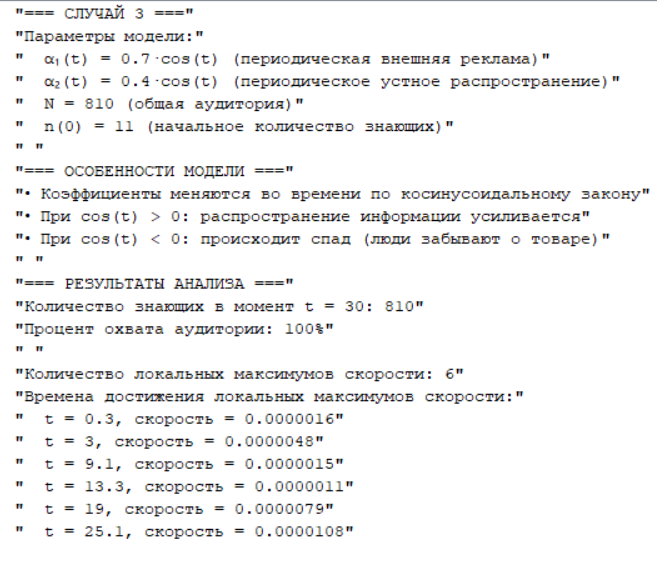